<h1 style="color:purple;">Entrenamiento de CNN con LINEX Function en su función de pérdida.</h1>
<p> Valentina Arce España <p>
<p> Febrero 17, 2026 <p>

<div class="alert alert-block alert-warning">
Aplicamos la misma metodología de la versión 2 pero con una CNN distinta.

2026-02-17 14:10:54.110800: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Cargando datos...
Reduciendo dataset de entrenamiento: Usando 2 de 9 motores.
Forma de X_train (reducido): (1060535, 32)
Generando ventanas (Step=10)...
Input Shape Train Final: (106045, 50, 32)
Input Shape Test Final: (372274, 50, 32)


/opt/miniconda3/envs/tesis_env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 177ms/step - loss: 199.5232 - val_loss: 10.6696
Epoch 2/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 34s 137ms/step - loss: 41.3401 - val_loss: 4.2623
Epoch 3/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 30s 161ms/step - loss: 32.1432 - val_loss: 4.0989
Epoch 4/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 31s 165ms/step - loss: 22.3669 - val_loss: 7.5662
Epoch 5/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 32s 170ms/step - loss: 22.8156 - val_loss: 3.0108
Epoch 6/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 194ms/step - loss: 23.1033 - val_loss: 2.6779
Epoch 7/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 39s 181ms/step - loss: 20.8594 - val_loss: 3.7751
Epoch 8/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 32s 172ms/step - loss: 17.7928 - val_loss: 0.9643
Epoch 9/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 46s 246ms/step - loss: 18.3799 - val_loss: 1.6298
Epoch 10/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - loss: 17.7228 - val_loss: 2.6304
Epoch 11/15
187/187 ━━━━━━━━━━━━━━━━━━━━ 35s 185ms/step - loss: 15.9188 - val_loss: 1.6737
Epoch 

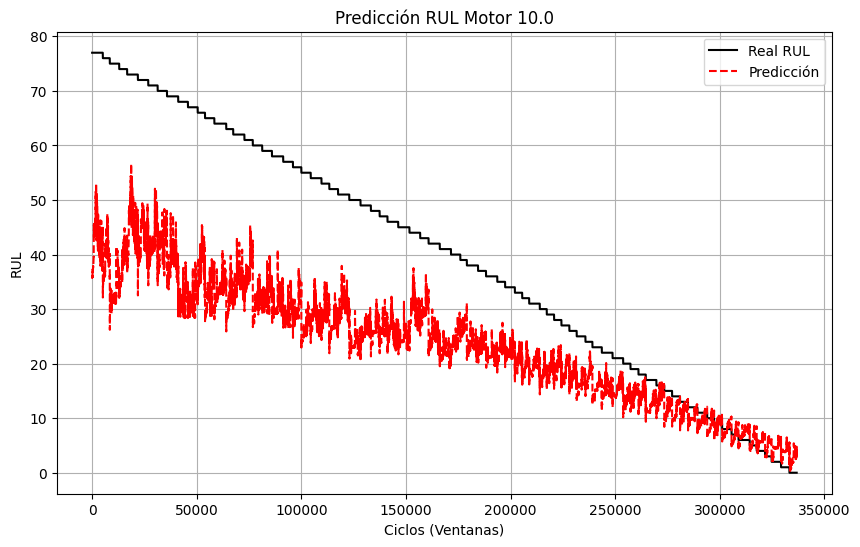

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow.keras import layers, models

# ==========================================
# 1. CONFIGURACIÓN (MODO AHORRO DE MEMORIA)
# ==========================================
filename = 'N-CMAPSS_DS08a-009.h5' 
WINDOW_SIZE = 50   
BATCH_SIZE = 512
EPOCHS = 15

# --- PARÁMETROS DE REDUCCIÓN ---
# Usar solo el 30% de los motores disponibles para entrenar (0.1 = 10%, 1.0 = 100%)
TRAIN_RATIO = 0.3  

# Salto al crear ventanas (Downsampling). 
# 1 = toma todas las ventanas posibles (máxima memoria).
# 10 = toma 1 ventana cada 10 segundos. Reduce el tamaño del dataset en 10x.
WINDOW_STEP = 10  

def load_data(filepath):
    with h5py.File(filepath, 'r') as hdf:
        # Development set (Train)
        W_dev = np.array(hdf.get('W_dev'))
        X_s_dev = np.array(hdf.get('X_s_dev'))
        X_v_dev = np.array(hdf.get('X_v_dev'))
        Y_dev = np.array(hdf.get('Y_dev'))
        A_dev = np.array(hdf.get('A_dev')) 
        
        # Test set
        W_test = np.array(hdf.get('W_test'))
        X_s_test = np.array(hdf.get('X_s_test'))
        X_v_test = np.array(hdf.get('X_v_test'))
        Y_test = np.array(hdf.get('Y_test'))
        A_test = np.array(hdf.get('A_test'))
        
        # Corrección de lectura de variables
        A_var = np.array(hdf.get('A_var'))
        A_var = list(np.array(A_var, dtype='U20'))
        
    return (W_dev, X_s_dev, X_v_dev, Y_dev, A_dev), (W_test, X_s_test, X_v_test, Y_test, A_test), A_var

print("Cargando datos...")
(train_W, train_Xs, train_Xv, train_Y, train_A), \
(test_W, test_Xs, test_Xv, test_Y, test_A), A_var = load_data(filename)

# ==========================================
# 2. REDUCCIÓN DE MOTORES (TRAIN)
# ==========================================
# Identificar unidades únicas en entrenamiento
train_units = np.unique(train_A[:, 0])
n_units_original = len(train_units)
n_units_keep = int(n_units_original * TRAIN_RATIO)

# Seleccionar solo las primeras N unidades
keep_units = train_units[:n_units_keep]

print(f"Reduciendo dataset de entrenamiento: Usando {n_units_keep} de {n_units_original} motores.")

# Filtrar los arrays de entrenamiento
# Buscamos los índices donde la columna unit (0) esté en nuestra lista keep_units
mask_train = np.isin(train_A[:, 0], keep_units)

train_W = train_W[mask_train]
train_Xs = train_Xs[mask_train]
train_Xv = train_Xv[mask_train]
train_Y = train_Y[mask_train]
train_A = train_A[mask_train]

# ==========================================
# 3. PREPROCESAMIENTO Y ESCALADO
# ==========================================
X_train = np.concatenate((train_W, train_Xs, train_Xv), axis=1)
X_test = np.concatenate((test_W, test_Xs, test_Xv), axis=1)

scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Forma de X_train (reducido): {X_train_scaled.shape}")

# ==========================================
# 4. GENERACIÓN DE VENTANAS CON SALTO (STEP)
# ==========================================
def create_windows(X, y, A, window_size, step=1, unit_col_index=0):
    unique_units = np.unique(A[:, unit_col_index])
    X_windows = []
    y_windows = []
    
    for unit in unique_units:
        idx = np.where(A[:, unit_col_index] == unit)[0]
        unit_X = X[idx, :]
        unit_y = y[idx]
        
        num_samples = len(unit_X)
        if num_samples < window_size:
            continue
            
        # APLICAMOS EL STEP AQUÍ PARA REDUCIR DATOS
        for i in range(0, num_samples - window_size + 1, step):
            X_windows.append(unit_X[i : i + window_size, :])
            y_windows.append(unit_y[i + window_size - 1])
            
    return np.array(X_windows), np.array(y_windows)

print(f"Generando ventanas (Step={WINDOW_STEP})...")
# Entrenamos con salto para ahorrar memoria
X_train_w, y_train_w = create_windows(X_train_scaled, train_Y, train_A, WINDOW_SIZE, step=WINDOW_STEP)

# Para test, generalmente queremos evaluar todo, pero si falla memoria, aumenta el step aquí también
X_test_w, y_test_w = create_windows(X_test_scaled, test_Y, test_A, WINDOW_SIZE, step=10) 

print(f"Input Shape Train Final: {X_train_w.shape}")
print(f"Input Shape Test Final: {X_test_w.shape}")

# ==========================================
# 5. MODELO CNN
# ==========================================
input_shape = (X_train_w.shape[1], X_train_w.shape[2])

model = models.Sequential()
# --- Esta es la parte que "quitas y pones" ---
model = models.Sequential()
model.add(layers.Conv1D(64, 3, activation='relu', input_shape=input_shape, padding='same')) # Más filtros
model.add(layers.Conv1D(64, 3, activation='relu', padding='same'))
model.add(layers.MaxPooling1D(2)) # Podrías añadir capas de Pooling
model.add(layers.Conv1D(128, 5, activation='relu', padding='same')) # Kernel más grande
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(64, activation='relu')) # Una capa densa extra
model.add(layers.Dense(1)) 
# ---------------------------------------------

model.compile(optimizer='adam', loss='mse')

# ==========================================
# 6. ENTRENAMIENTO
# ==========================================
history = model.fit(
    X_train_w, y_train_w,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# 7. EVALUACIÓN
# ==========================================
print("Prediciendo...")
y_pred = model.predict(X_test_w)
rmse = np.sqrt(mean_squared_error(y_test_w, y_pred))
print(f"\nRMSE Global en Test: {rmse:.4f}")

# Visualización (Primer motor del test)
test_units = np.unique(test_A[:, 0])
target_unit = test_units[0]
idx_unit = np.where(test_A[:, 0] == target_unit)[0]

# Extraemos solo datos de ese motor para graficar limpio
unit_X_scaled = X_test_scaled[idx_unit]
unit_y_raw = test_Y[idx_unit]
# Usamos step=1 aquí para tener la gráfica bonita y suave, aunque tarde un poco más en predecir
X_unit_w, y_unit_w = create_windows(unit_X_scaled, unit_y_raw, test_A[idx_unit], WINDOW_SIZE, step=1)
y_unit_pred = model.predict(X_unit_w)

plt.figure(figsize=(10, 6))
plt.plot(y_unit_w, label='Real RUL', color='black')
plt.plot(y_unit_pred, label='Predicción', color='red', linestyle='--')
plt.title(f'Predicción RUL Motor {target_unit}')
plt.xlabel('Ciclos (Ventanas)')
plt.ylabel('RUL')
plt.legend()
plt.grid(True)
plt.show()

In [2]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import load_model
import tensorflow.keras.backend as K

# --- PASO 1: DEFINIR LA FUNCIÓN LINEX ---
def linex_loss(y_true, y_pred):
    a = -0.1  # Penalización para predicciones tardías
    error = y_true - y_pred
    loss = K.exp(a * error) - (a * error) - 1
    return K.mean(loss)

In [3]:
# --- PASO 2: CREAR LA COPIA (CLONAR EL MODELO ENTRENADO) ---
# Primero guardamos el modelo actual (MSE) en disco por seguridad
model.save('modelo_mse_temporal_02.keras')

In [4]:
# Luego lo cargamos en una NUEVA variable llamada 'model_linex'
# (Esto es lo que te faltaba: "llamar al modelo")
model_linex = load_model('modelo_mse_temporal_02.keras')

In [5]:
# --- PASO 3: RE-ENTRENAR CON LINEX (FINE-TUNING) ---
print("Compilando con LINEX...")

# Usamos un learning rate bajito (0.0001) para no dañar los pesos que ya aprendió
model_linex.compile(optimizer=Adam(learning_rate=0.0001), loss=linex_loss)

print("Iniciando Fine-Tuning con LINEX...")
history_linex = model_linex.fit(
    X_train_w, y_train_w,
    epochs=10, 
    batch_size=512,
    validation_split=0.1,
    verbose=1
)

print("¡Entrenamiento LINEX finalizado!")

Compilando con LINEX...
Iniciando Fine-Tuning con LINEX...
Epoch 1/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 183ms/step - loss: 0.0505 - val_loss: 0.0162
Epoch 2/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - loss: 0.0484 - val_loss: 0.0170
Epoch 3/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 26s 141ms/step - loss: 0.0480 - val_loss: 0.0129
Epoch 4/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 126ms/step - loss: 0.0459 - val_loss: 0.0154
Epoch 5/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 20s 104ms/step - loss: 0.0456 - val_loss: 0.0136
Epoch 6/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 102ms/step - loss: 0.0441 - val_loss: 0.0147
Epoch 7/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - loss: 0.0452 - val_loss: 0.0150
Epoch 8/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 124ms/step - loss: 0.0438 - val_loss: 0.0173
Epoch 9/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - loss: 0.0435 - val_loss: 0.0153
Epoch 10/10
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 122ms/step - loss: 0.0417 - val_loss: 0.0151
¡Entrenamiento LINEX finalizado!


In [6]:
# Evaluar ambos modelos en el set de test completo
y_pred_mse = model.predict(X_test_w, verbose=0)
y_pred_linex = model_linex.predict(X_test_w, verbose=0)

rmse_mse = np.sqrt(mean_squared_error(y_test_w, y_pred_mse))
rmse_linex = np.sqrt(mean_squared_error(y_test_w, y_pred_linex))

# Calcular el error promedio (Bias)
# Un error positivo significa que el modelo es conservador (predice RUL menor al real)
bias_mse = np.mean(y_test_w - y_pred_mse)
bias_linex = np.mean(y_test_w - y_pred_linex)

print(f"--- COMPARATIVA FINAL ---")
print(f"MSE Model   | RMSE: {rmse_mse:.4f} | Bias: {bias_mse:.4f}")
print(f"LINEX Model | RMSE: {rmse_linex:.4f} | Bias: {bias_linex:.4f}")

--- COMPARATIVA FINAL ---
MSE Model   | RMSE: 8.4895 | Bias: -0.7690
LINEX Model | RMSE: 8.1539 | Bias: 0.6356


Generando comparativa para el Motor 13...


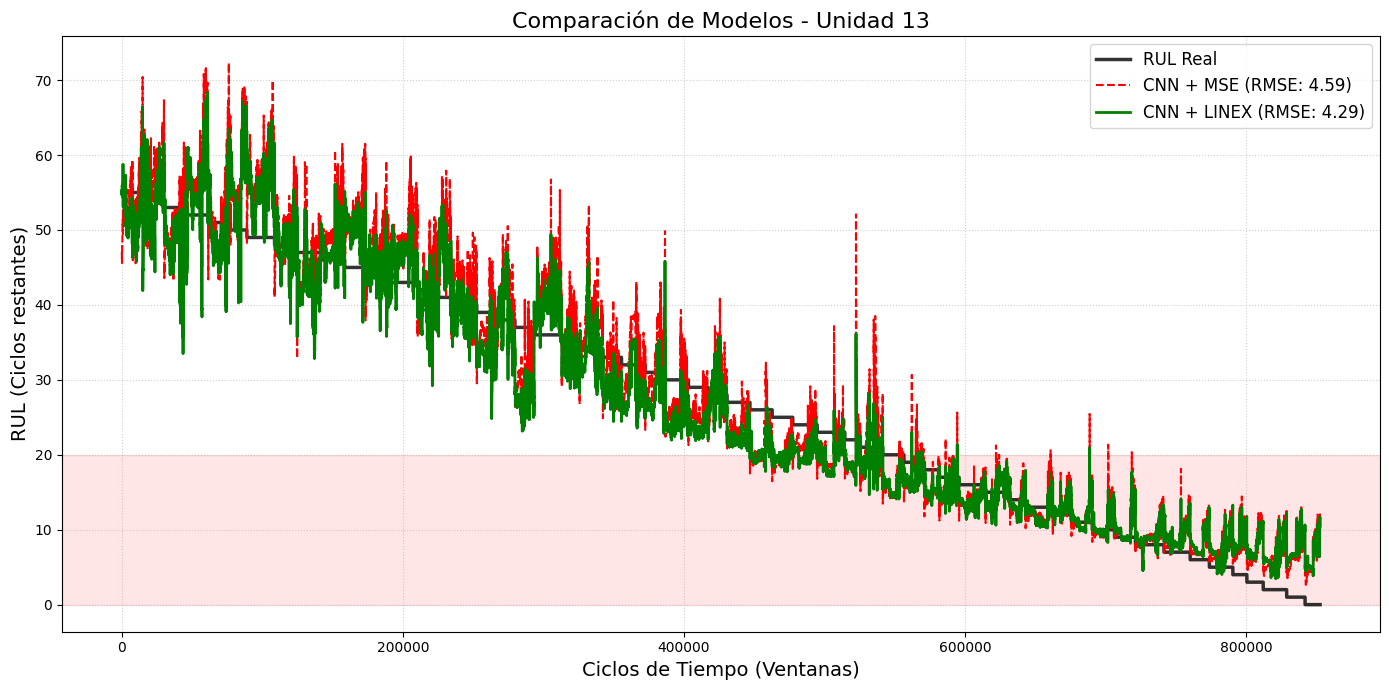

In [7]:
def comparar_resultados_motores(unit_id):
    """
    Grafica la comparación entre el modelo MSE (Original) y el modelo LINEX (Refinado)
    para una unidad específica del set de test.
    """
    print(f"Generando comparativa para el Motor {unit_id}...")
    
    # 1. Filtrar datos de la unidad elegida
    idx = np.where(test_A[:, 0] == unit_id)[0]
    
    if len(idx) == 0:
        print(f"Error: El motor {unit_id} no se encuentra en el set de Test.")
        return

    # 2. Extraer y preparar ventanas (paso 1 para máxima resolución)
    unit_X = X_test_scaled[idx]
    unit_y = test_Y[idx]
    
    # Reutilizamos la función create_windows que definimos antes
    X_w, y_real = create_windows(unit_X, unit_y, test_A[idx], WINDOW_SIZE, step=1)
    
    # 3. Realizar predicciones con ambos modelos
    # 'model' es el de MSE y 'model_linex' es el de LINEX
    pred_mse = model.predict(X_w, verbose=0)
    pred_linex = model_linex.predict(X_w, verbose=0)
    
    # 4. Calcular RMSE individual para el reporte en el título
    rmse_mse = np.sqrt(mean_squared_error(y_real, pred_mse))
    rmse_linex = np.sqrt(mean_squared_error(y_real, pred_linex))
    
    # 5. GRAFICAR
    plt.figure(figsize=(14, 7))
    
    # Línea Real
    plt.plot(y_real, label='RUL Real', color='black', linewidth=2.5, alpha=0.8)
    
    # Predicción MSE
    plt.plot(pred_mse, label=f'CNN + MSE (RMSE: {rmse_mse:.2f})', 
             color='red', linestyle='--', linewidth=1.5)
    
    # Predicción LINEX
    plt.plot(pred_linex, label=f'CNN + LINEX (RMSE: {rmse_linex:.2f})', 
             color='green', linewidth=2)
    
    # Estética de la gráfica
    plt.title(f'Comparación de Modelos - Unidad {unit_id}', fontsize=16)
    plt.xlabel('Ciclos de Tiempo (Ventanas)', fontsize=14)
    plt.ylabel('RUL (Ciclos restantes)', fontsize=14)
    plt.legend(loc='upper right', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # Añadir una zona de "Falla Crítica" sombreada para mayor impacto visual
    plt.axhspan(0, 20, color='red', alpha=0.1, label='Zona Crítica')
    
    plt.tight_layout()
    plt.show()

# --- Ejecución para el motor 13 ---
comparar_resultados_motores(13)

# También puedes probar con otros motores rápidamente:
# comparar_resultados_motores(14)
# comparar_resultados_motores(15)

In [8]:
model_linex.save('modelo_mse_temporal_linex_02.keras')